# 1. Settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# 2. Sold Data 

In [ ]:
df_sold = pd.read_csv("sold_residential.csv")


C:\Users\junki\AppData\Local\Temp\ipykernel_10564\2745887180.py:1: DtypeWarning: Columns (0: BuyerAgencyCompensationType) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sold = pd.read_csv("sold_residential.csv")
C:\Users\junki\AppData\Local\Temp\ipykernel_10564\2745887180.py:2: DtypeWarning: Columns (0: BuyerAgencyCompensationType) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = pd.read_csv("listing_residential.csv")


In [3]:
print(df_sold.shape)
df_sold.head()

(430075, 61)


,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,...,Stories,HighSchool,Levels,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,MiddleOrJuniorSchoolDistrict,BuyerAgencyCompensationType,BuyerAgencyCompensation
0,NaN,True,NaN,NaN,True,598000.0,1048490409,2024-01-01,555000.0,Shelli,...,1.0,NaN,One,False,2.0,Riverside Unified,92504,NaN,NaN,NaN
1,Laminate,False,NaN,NaN,False,915000.0,1046722825,2024-01-01,915000.0,Esperanza,...,2.0,NaN,Two,NaN,2.0,Moorpark Unified,93021,NaN,NaN,NaN
2,Wood,True,NaN,NaN,False,184500.0,1048590625,2024-01-01,186500.0,Nathan,...,1.0,NaN,One,False,0.0,NaN,92026,NaN,NaN,NaN
3,NaN,True,NaN,NaN,False,1600000.0,1054052014,2024-01-01,1600000.0,Joseph,...,2.0,NaN,Two,False,2.0,NaN,92054,NaN,NaN,NaN
4,"Laminate,Tile",False,NaN,NaN,False,535000.0,1046369026,2024-01-01,535000.0,Gustavo,...,1.0,NaN,One,False,2.0,Rialto Unified,92376,NaN,NaN,NaN


We have 430075 properties in California with 61 features of the real estate market features.

In [4]:
pd.set_option("display.max_rows", None)

Let's check missing values in sold dataset. First, we will identify and flag on features that have more than 90% of missing values.

In [5]:
# check all features for percentage of missing values
missing_ratio = df_sold.isna().sum() / df_sold.shape[0]
print(missing_ratio.sort_values(ascending=False))

# call features that contain more than 90% of missing values
missing_high = missing_ratio[missing_ratio>=0.9]
print()
print("Missing more than 90%")
print(missing_high.sort_values(ascending=False))

TaxAnnualAmount                 1.000000
FireplacesTotal                 1.000000
MiddleOrJuniorSchoolDistrict    1.000000
ElementarySchoolDistrict        1.000000
TaxYear                         1.000000
BusinessType                    1.000000
WaterfrontYN                    0.999370
BasementYN                      0.980399
BuilderName                     0.951041
BuyerAgencyCompensation         0.892802
BuyerAgencyCompensationType     0.892777
ElementarySchool                0.866986
MiddleOrJuniorSchool            0.866100
HighSchool                      0.826095
SubdivisionName                 0.627509
Flooring                        0.358775
HighSchoolDistrict              0.275336
Stories                         0.153648
AttachedGarageYN                0.152792
MLSAreaMajor                    0.134191
Levels                          0.096002
PoolPrivateYN                   0.085897
ViewYN                          0.085504
LotSizeAcres                    0.078198
NewConstructionY

The missning values more than 90% are **FireplacesTotal**, **BusinessType**, **TaxAnnualAmount**, **ElementarySchoolDistrict**,**TaxYear**,**MiddleOrJuniorSchoolDistrict**,**WaterfrontYN**,**BasementYN**, and **BuilderName**. We will drop those missing values and those are not strongly relevant from identifying housing market features.

In [6]:
# drop features over 90% missing values
df_sold = df_sold.drop(columns = missing_high.index)

(df_sold.isna().sum() / df_sold.shape[0]) >= 0.9

Flooring                       False
ViewYN                         False
PoolPrivateYN                  False
OriginalListPrice              False
ListingKey                     False
CloseDate                      False
ClosePrice                     False
ListAgentFirstName             False
ListAgentLastName              False
Latitude                       False
Longitude                      False
UnparsedAddress                False
PropertyType                   False
LivingArea                     False
ListPrice                      False
DaysOnMarket                   False
ListOfficeName                 False
BuyerOfficeName                False
ListAgentFullName              False
BuyerAgentMlsId                False
BuyerAgentFirstName            False
BuyerAgentLastName             False
ListingKeyNumeric              False
MLSAreaMajor                   False
CountyOrParish                 False
MlsStatus                      False
ElementarySchool               False
A

In [7]:
# call features have missing values between 60% to 90%
missing_mid = missing_ratio[(missing_ratio>=0.6)&(missing_ratio<0.9)]
missing_mid.sort_values(ascending=False)

BuyerAgencyCompensation        0.892802
BuyerAgencyCompensationType    0.892777
ElementarySchool               0.866986
MiddleOrJuniorSchool           0.866100
HighSchool                     0.826095
SubdivisionName                0.627509
dtype: float64

These are the features that are not consistently reported across the dataset, because more than half of records are missing. For this analysis, we identified as high missing features 60% to 90% that we avoid using them for major conclusions unless we specifically focus on the subset of records.



**BuyerAgencyCompensation** and **BuyerAgencyCompensationType** are missing high because buyers agent compensation became more complicated after 2024 National Association of Realtors (NAR) settlement changes. The real estate primer says buyer agent compensation is not negociated separetly rather than automatically offered through the Multiple Listing Service (MLS).

NAR  refers to major 2024 rule changes after lawsuits about real estate commissions. Before the settlement, many MLS systems showed how much compensation the seller/listing broker was offering to the buyer’s agent. After the settlement changes, offers of compensation are no longer allowed on MLS platforms, although sellers can still offer compensation outside the MLS through negotiation.

The school information is highly missing probably because is often optional, inconsistent, or location-dependent in MLS data. A property can be near one school but assigned to another school district or boundary.

SubdivisionName is also often optional. It is more common in planned communities, newer developments, HOA neighborhoods, or tract housing. But many older homes, rural properties, or urban properties may not have a formal subdivision name

In [8]:
# call features have missing values between 30% to 60%
missing_mid_low = missing_ratio[(missing_ratio>=0.3)&(missing_ratio<0.6)]
missing_mid_low.sort_values(ascending=False)

Flooring    0.358775
dtype: float64

Flooring feature had moderate missing values of 35.88% that one-third of records did not report flooring information, and we should interpret with caution.


## 1) Explicit Implicit Missing Values
Let's identify if there is implicit missing values.

In [9]:
# Listing data types
df_sold.dtypes

Flooring                           str
ViewYN                          object
PoolPrivateYN                   object
OriginalListPrice              float64
ListingKey                       int64
CloseDate                          str
ClosePrice                     float64
ListAgentFirstName                 str
ListAgentLastName                  str
Latitude                       float64
Longitude                      float64
UnparsedAddress                    str
PropertyType                       str
LivingArea                     float64
ListPrice                      float64
DaysOnMarket                     int64
ListOfficeName                     str
BuyerOfficeName                    str
ListAgentFullName                  str
BuyerAgentMlsId                    str
BuyerAgentFirstName                str
BuyerAgentLastName                 str
ListingKeyNumeric                int64
MLSAreaMajor                       str
CountyOrParish                     str
MlsStatus                

Let's divide features into each data types

In [10]:
# divide features into each data types
numeric = [
    'OriginalListPrice',
    'ClosePrice',
    'Latitude',
    'Longitude',
    'LivingArea',
    'ListPrice',
    'ParkingTotal',
    'YearBuilt',
    'BathroomsTotalInteger',
    'Stories',
    'GarageSpaces',
    'LotSizeAcres',
    'BuyerAgencyCompensation'
]

discrete = [
    'DaysOnMarket',
    'BedroomsTotal'
]

categorical = [
    'Flooring',
    'ViewYN',
    'PoolPrivateYN',
    'ListAgentFirstName',
    'ListAgentLastName',
    'UnparsedAddress',
    'PropertyType',
    'ListOfficeName',
    'BuyerOfficeName',
    'ListAgentFullName',
    'BuyerAgentMlsId',
    'BuyerAgentFirstName',
    'BuyerAgentLastName',
    'MLSAreaMajor',
    'CountyOrParish',
    'MlsStatus',
    'ElementarySchool',
    'AttachedGarageYN',
    'PropertySubType',
    'SubdivisionName',
    'City',
    'StateOrProvince',
    'MiddleOrJuniorSchool',
    'FireplaceYN',
    'HighSchool',
    'Levels',
    'NewConstructionYN',
    'HighSchoolDistrict',
    'PostalCode',
    'BuyerAgencyCompensationType'
]

date_feature = [
    'CloseDate',
    'ContractStatusChangeDate',
    'PurchaseContractDate',
    'ListingContractDate'
]

id_feature = [
    'ListingKey',
    'ListingKeyNumeric',
    'ListingId'
]

Let's identify the numeric explicit and implicit missing values.

In [11]:
# numeric data types
df_sold[numeric+discrete].dtypes

OriginalListPrice          float64
ClosePrice                 float64
Latitude                   float64
Longitude                  float64
LivingArea                 float64
ListPrice                  float64
ParkingTotal               float64
YearBuilt                  float64
BathroomsTotalInteger      float64
Stories                    float64
GarageSpaces               float64
LotSizeAcres               float64
BuyerAgencyCompensation    float64
DaysOnMarket                 int64
BedroomsTotal              float64
dtype: object

All numeric features show float64 or int64 that there is no implicit missing values.

In [12]:
# percentage of explicit missing values
df_sold[numeric+discrete].isna().sum()/df_sold.shape[0]

OriginalListPrice          0.001835
ClosePrice                 0.000002
Latitude                   0.037389
Longitude                  0.037389
LivingArea                 0.000570
ListPrice                  0.000000
ParkingTotal               0.000991
YearBuilt                  0.000888
BathroomsTotalInteger      0.000163
Stories                    0.153648
GarageSpaces               0.042983
LotSizeAcres               0.078198
BuyerAgencyCompensation    0.892802
DaysOnMarket               0.000000
BedroomsTotal              0.000028
dtype: float64

Excep the BuyersAgencyCompensation, numeric features have minimal percentage of explicit missing values.

Let's identify the date features.

In [13]:
# date feature data type
df_sold[date_feature].dtypes

CloseDate                   str
ContractStatusChangeDate    str
PurchaseContractDate        str
ListingContractDate         str
dtype: object

In [14]:
# list of implicit missing values
implicit_missing_values = [
    '',
    ' ',
    'Unknown',
    'unknown',
    'UNKNOWN',
    'N/A',
    'NA',
    'na',
    'None',
    'none',
    'NULL',
    'null',
    '--',
    '-',
    'Missing',
    'missing'
]

# scan implicit missing values match with date features
for i in date_feature:
    col = df_sold[i]
    implicit = col[col.isin(implicit_missing_values)].unique().tolist()
    print(f"{i} feature of values")
    print(implicit)
    print()

CloseDate feature of values
[]

ContractStatusChangeDate feature of values
[]

PurchaseContractDate feature of values
[]

ListingContractDate feature of values
[]



There is no implicit missing values in date features.

In [15]:
# percentage of expllicit missing value for date features.
df_sold[date_feature].isna().sum()/df_sold.shape[0]

CloseDate                   0.000000
ContractStatusChangeDate    0.001370
PurchaseContractDate        0.000458
ListingContractDate         0.000002
dtype: float64

However, there are explicit missing values less than 1%

Let's identify the listing key features.

In [16]:
# show listing key features
df_sold[id_feature].dtypes

ListingKey           int64
ListingKeyNumeric    int64
ListingId              str
dtype: object

In [17]:
# scan implicit missing value in listing features
for i in id_feature:
    col = df_sold[i]
    implicit = col[col.isin(implicit_missing_values)].unique().tolist()
    print(f"{i} feature of values")
    print(implicit)
    print()

ListingKey feature of values
[]

ListingKeyNumeric feature of values
[]

ListingId feature of values
[]



There is no implicit missing values in listing key features.

In [18]:
# percentage explicit missing values
df_sold[id_feature].isna().sum()/df_sold.shape[0]

ListingKey           0.0
ListingKeyNumeric    0.0
ListingId            0.0
dtype: float64

There is no explicit missing values as well. 

Let's identify the categorical features.

In [19]:
# list data types for categorical
df_sold[categorical].dtypes

Flooring                          str
ViewYN                         object
PoolPrivateYN                  object
ListAgentFirstName                str
ListAgentLastName                 str
UnparsedAddress                   str
PropertyType                      str
ListOfficeName                    str
BuyerOfficeName                   str
ListAgentFullName                 str
BuyerAgentMlsId                   str
BuyerAgentFirstName               str
BuyerAgentLastName                str
MLSAreaMajor                      str
CountyOrParish                    str
MlsStatus                         str
ElementarySchool                  str
AttachedGarageYN               object
PropertySubType                   str
SubdivisionName                   str
City                              str
StateOrProvince                   str
MiddleOrJuniorSchool              str
FireplaceYN                    object
HighSchool                        str
Levels                            str
NewConstruct

In [20]:
# scan implicit missing values for categorical

for i in categorical:
    col = df_sold[i]
    implicit = col[col.isin(implicit_missing_values)].unique().tolist()
    print(f"{i} feature of values")
    print(implicit)
    print()

Flooring feature of values
[]

ViewYN feature of values
[]

PoolPrivateYN feature of values
[]

ListAgentFirstName feature of values
['-']

ListAgentLastName feature of values
[]

UnparsedAddress feature of values
[]

PropertyType feature of values
[]

ListOfficeName feature of values
[]

BuyerOfficeName feature of values
['UNKNOWN']

ListAgentFullName feature of values
[]

BuyerAgentMlsId feature of values
['none']

BuyerAgentFirstName feature of values
['Unknown', '-', 'none']

BuyerAgentLastName feature of values
['UNKNOWN', '-', 'none']

MLSAreaMajor feature of values
[]

CountyOrParish feature of values
[]

MlsStatus feature of values
[]

ElementarySchool feature of values
['Unknown']

AttachedGarageYN feature of values
[]

PropertySubType feature of values
[]

SubdivisionName feature of values
['none', 'Unknown', 'unknown', 'UNKNOWN', '-', 'na']

City feature of values
['Unknown']

StateOrProvince feature of values
[]

MiddleOrJuniorSchool feature of values
[]

FireplaceYN featur

There are couple implicit missing values in **BuyeerOfficeName**, **BuyerAgentMlsId**, **BuyerAgentFirstName**, **BuyerAgentLastName**, **ElementarySchool**, **SubdivisionName**, **City**, and **HighSchool**. 

In [21]:
df_sold[categorical].isna().sum() / df_sold.shape[0]

Flooring                       0.358775
ViewYN                         0.085504
PoolPrivateYN                  0.085897
ListAgentFirstName             0.007445
ListAgentLastName              0.000093
UnparsedAddress                0.000981
PropertyType                   0.000000
ListOfficeName                 0.000000
BuyerOfficeName                0.016158
ListAgentFullName              0.000219
BuyerAgentMlsId                0.001279
BuyerAgentFirstName            0.004781
BuyerAgentLastName             0.000409
MLSAreaMajor                   0.134191
CountyOrParish                 0.000000
MlsStatus                      0.000000
ElementarySchool               0.866986
AttachedGarageYN               0.152792
PropertySubType                0.001937
SubdivisionName                0.627509
City                           0.000732
StateOrProvince                0.000000
MiddleOrJuniorSchool           0.866100
FireplaceYN                    0.000807
HighSchool                     0.826095


Except **CountyOrParish**, **MlsStatus**, **ListOfficeName**, **PropertyType**, and **StateOrProvince**, other categorical features contain explicit missing values.

# 4. Explanatory Data Analysis

## 1) Close Price

We will explore the close price considering mainstream of the close price in California.

In [22]:
df_sold[df_sold["ClosePrice"]<0]

,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,...,FireplaceYN,Stories,HighSchool,Levels,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerAgencyCompensationType,BuyerAgencyCompensation


In [23]:
# summary of close price
df_sold["ClosePrice"].describe()

count    4.300740e+05
mean     1.193425e+06
std      6.176701e+06
min      0.000000e+00
25%      5.750000e+05
50%      8.250000e+05
75%      1.300000e+06
max      9.895000e+08
Name: ClosePrice, dtype: float64

The typical housing close price as median is 825,000 dollars. The overall price as mean is 1,193,425 dollars. The most expensive housing close price is 989,500,000 dollars. This suggest that minor expensive properties presenting average to be pulling upward compare to typical properties.

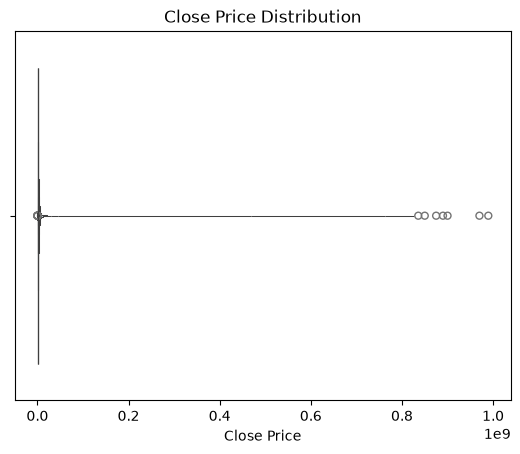

In [24]:
# boxplot for close price distribution
sns.boxenplot(x=df_sold["ClosePrice"])
plt.title("Close Price Distribution")
plt.xlabel("Close Price")
plt.show()

Most of properties have much lower close price values, but a few extremely large prices strech out that distribution is highly right skewed.

Let's exclude the extreme properties in temperatory over 99% close price properties for identifying broad trend of close price.

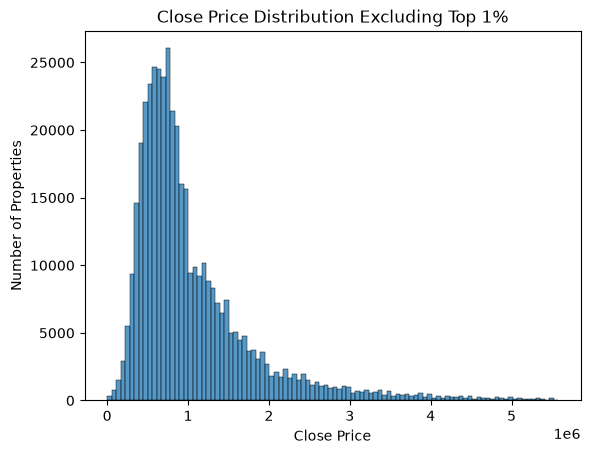

In [25]:
upper_limit = df_sold["ClosePrice"].quantile(0.99)

sns.histplot(df_sold[df_sold["ClosePrice"] <= upper_limit]["ClosePrice"], bins=100)
plt.title("Close Price Distribution Excluding Top 1%")
plt.xlabel("Close Price")
plt.ylabel("Number of Properties")
plt.show()

The close price distribution is right skewed. Most of properties sold below about 1.3 million dollars, but a small number of expensive properties increase the mean. 

### a) Close Price + List Price & Original List Price.

In the sold dataset, list price and original list price are there because a sold property still has its listing history, explaining how the sale happened. 

- List price is the current price of the property as tetermined by the seller and the seller's broker

- Original list price is the initial agreement between the seller and seller's broker.

We will explore how those prices went forward until the sold price.

Let's check if there is error listed for list and original list price aamong properties that has been sold.

In [26]:
df_sold[df_sold["ListPrice"]<0]

,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,...,FireplaceYN,Stories,HighSchool,Levels,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerAgencyCompensationType,BuyerAgencyCompensation


In [27]:
df_sold[df_sold["OriginalListPrice"]<0]

,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,...,FireplaceYN,Stories,HighSchool,Levels,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerAgencyCompensationType,BuyerAgencyCompensation


There is no invalid value. 

We will make new features of **SaleListRatio**, **DiffCloseList**, and **PriceReduction**. 

- **SaleListRatio** measures whether homes sold above or below the final asking price.

- **DiffCloseList** measures the price difference between the final sale and final list price. 

- **PriceReduction** measures whether the seller reduced the price from original list price before sale.

There were couple missing values in the sold dataset that close price has 0.0002%, list price has 0% and original list price has 0.1835%. We will remove those minimal missing price properties that will cause less performance analysis.

In [28]:
# make new features of the performance among close, list, original list prices
df_sold = df_sold.dropna(subset = ["ClosePrice", "ListPrice", "OriginalListPrice"])

df_sold["SaleListRatio"] = df_sold["ClosePrice"] / df_sold["ListPrice"]

df_sold["DiffCloseList"] = df_sold["ClosePrice"] - df_sold["ListPrice"]

df_sold["PriceReduction"] = df_sold["OriginalListPrice"] - df_sold["ListPrice"]


Let's explore those values.

In [29]:
df_sold[["SaleListRatio","DiffCloseList", "PriceReduction"]].describe()

,SaleListRatio,DiffCloseList,PriceReduction
count,429285.000000,4.292850e+05,4.292850e+05
mean,1.084084,5.148012e+04,8.681117e+04
std,8.767749,6.052115e+06,6.542206e+06
min,0.000000,-2.750000e+07,-1.035000e+07
25%,0.976364,-1.990000e+04,0.000000e+00
50%,1.000000,0.000000e+00,0.000000e+00
75%,1.019726,1.500000e+04,1.000000e+04
max,1153.846154,9.885210e+08,1.388810e+09


**Ratio**

- The median is 1, meaning the typical home sold exactly at asking price, asking between 0.97 and 1.0197.

-  Most homes sold from about 2.36% were below asking, and 1.96% above asking the housing price.

- The mean is 1.084, which it is higher than median. This probably because of extreme outliers, especially 1153.85. This is not realistic for normal housing data. It means one property's close price was over 1,153 times its listing price. This probably happened because list price was extremely low, wrong, or entered invalid value.

- We might be cautious on interpreting mean ratio.

**Difference of close and list price**

- The median 0, presenting that typical housing sold at asking price, asking between 19,900 dollars below asking, and 15,000 dollars above asking.

- The max of difference was 988,521,000 dollars that extremely large and likely an outlier or data quality issue. That huge value is pulling the mean upward to 51,385 dollars differences between close and listing price.

- We might need to be cautious intperting mean difference.

**Price Reduction**

- The median 0, presenting that typical houses had no price reduction, but 75% of properties were 10,000 dollars or less reduction been sold. 

- The max reduction price was 1.39 billion dollars, that original price was 1.39 billion dollars higher than final sale price. This is likely error or unusual commercial record. 

## 2) Living Area

In [32]:
df_sold = df_sold.dropna(subset=["LivingArea"])

df_sold.shape

(429040, 55)

In [33]:
df_sold["LivingArea"].describe()

count    4.290400e+05
mean     1.904221e+03
std      2.600305e+04
min      0.000000e+00
25%      1.248000e+03
50%      1.644000e+03
75%      2.221000e+03
max      1.702132e+07
Name: LivingArea, dtype: float64

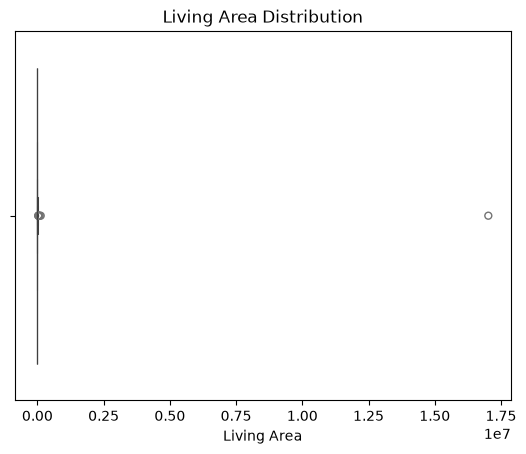

In [34]:
sns.boxenplot(x=df_sold["LivingArea"])
plt.title("Living Area Distribution")
plt.xlabel("Living Area")
plt.show()

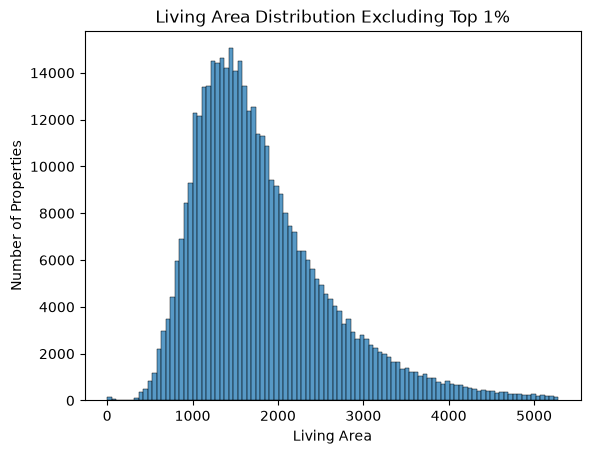

In [35]:
upper_limit = df_sold["LivingArea"].quantile(0.99)

sns.histplot(df_sold[df_sold["LivingArea"] <= upper_limit]["LivingArea"], bins=100)
plt.title("Living Area Distribution Excluding Top 1%")
plt.xlabel("Living Area")
plt.ylabel("Number of Properties")
plt.show()

## 3) Lot Size

In [36]:
df_sold["LotSizeAcres"].describe()

count    3.955620e+05
mean     6.420091e+01
std      1.571184e+04
min      0.000000e+00
25%      1.200000e-01
50%      1.665000e-01
75%      2.732000e-01
max      7.810698e+06
Name: LotSizeAcres, dtype: float64

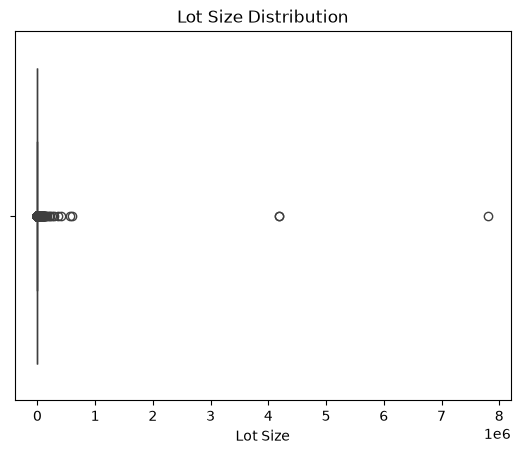

In [37]:
sns.boxplot(x=df_sold["LotSizeAcres"])
plt.title("Lot Size Distribution")
plt.xlabel("Lot Size")
plt.show()

In [38]:
upper_limit = df_sold["LotSizeAcres"].quantile(0.99)


print(df_sold[df_sold["LotSizeAcres"]>=upper_limit].shape)
print(df_sold[df_sold["LotSizeAcres"]>=upper_limit]["LotSizeAcres"].sort_values(ascending=False))
df_sold[df_sold["LotSizeAcres"]>=upper_limit].head()

(3956, 55)
47019     7.810698e+06
286304    4.187292e+06
253419    4.187292e+06
153531    6.048240e+05
145526    5.718370e+05
50050     4.064320e+05
350318    3.549900e+05
199922    2.870600e+05
209670    2.480810e+05
198643    2.143360e+05
368970    2.030000e+05
195600    1.585990e+05
91273     1.451600e+05
328515    1.276310e+05
23749     1.272050e+05
401636    1.209720e+05
119191    1.179440e+05
87684     1.167410e+05
384674    1.160540e+05
307773    9.409000e+04
130702    8.995000e+04
227294    8.903700e+04
378223    8.889500e+04
332693    8.886200e+04
342446    8.799100e+04
135335    8.799100e+04
133838    8.743000e+04
393379    8.712000e+04
117672    8.712000e+04
132075    8.624800e+04
369214    8.476800e+04
167564    8.128200e+04
347683    8.011200e+04
313614    7.248700e+04
227321    7.149600e+04
260979    6.839300e+04
201303    6.779016e+04
107053    6.401300e+04
269110    6.359800e+04
341133    6.359700e+04
377050    6.011300e+04
270970    6.011200e+04
389194    5.924100e+04


,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,...,Levels,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerAgencyCompensationType,BuyerAgencyCompensation,SaleListRatio,DiffCloseList,PriceReduction
2,Wood,True,False,184500.0,1048590625,2024-01-01,186500.0,Nathan,Barkley,NaN,...,One,False,0.0,NaN,92026,NaN,NaN,1.021918,4000.0,2000.0
7,NaN,True,False,610000.0,1054027980,2024-01-01,610000.0,Tyson,Dexter,34.151757,...,One,False,0.0,Las Virgenes,91302,NaN,NaN,1.000000,0.0,0.0
73,NaN,True,False,819000.0,1046466497,2024-01-02,720000.0,Jessica,Simmons,39.821453,...,One,False,2.0,Chico Unified,95973,NaN,NaN,0.923077,-60000.0,39000.0
251,"Carpet,Tile",False,False,529000.0,1045232329,2024-01-02,460000.0,Laura,Benvenuto,33.709040,...,One,False,0.0,Irvine Unified,92660,NaN,NaN,0.989247,-5000.0,64000.0
375,NaN,True,False,325000.0,1044789810,2024-01-02,250000.0,Andre,Holmes,39.065973,...,One,False,0.0,Lake,95423,NaN,NaN,0.877193,-35000.0,40000.0


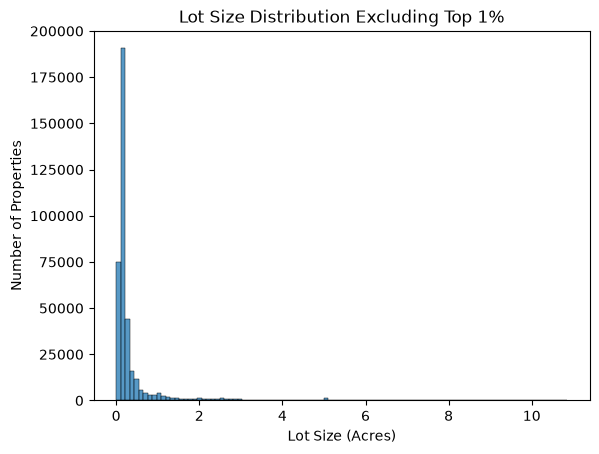

In [39]:
sns.histplot(df_sold[df_sold["LotSizeAcres"] <= upper_limit]["LotSizeAcres"], bins=100)
plt.title("Lot Size Distribution Excluding Top 1%")
plt.xlabel("Lot Size (Acres)")
plt.ylabel("Number of Properties")
plt.show()

## 4) Bedrooms

In [40]:
df_sold["BedroomsTotal"].describe()

count    429040.000000
mean          3.203193
std           1.065929
min           0.000000
25%           3.000000
50%           3.000000
75%           4.000000
max          45.000000
Name: BedroomsTotal, dtype: float64

In [41]:
df_sold["BedroomsTotal"].value_counts(normalize=True).sort_values(ascending=False)

BedroomsTotal
3.0     0.397606
4.0     0.265877
2.0     0.204014
5.0     0.077893
1.0     0.033855
6.0     0.013668
7.0     0.002776
0.0     0.002760
8.0     0.000932
9.0     0.000301
10.0    0.000152
11.0    0.000049
12.0    0.000042
13.0    0.000019
15.0    0.000016
16.0    0.000012
14.0    0.000007
34.0    0.000002
23.0    0.000002
31.0    0.000002
18.0    0.000002
17.0    0.000002
45.0    0.000002
19.0    0.000002
20.0    0.000002
22.0    0.000002
24.0    0.000002
Name: proportion, dtype: float64

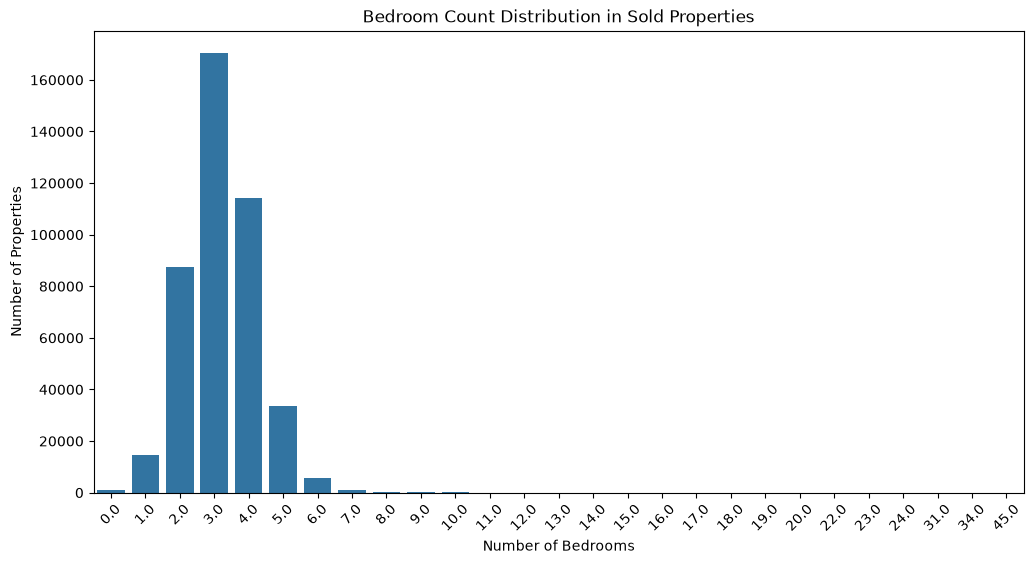

In [70]:
plt.figure(figsize=(12, 6))
sns.countplot(x="BedroomsTotal", data = df_sold)
plt.xticks(rotation=45)
plt.title("Bedroom Count Distribution in Sold Properties")
plt.xlabel('Number of Bedrooms')
plt.ylabel("Number of Properties")
plt.show()

## 5) Bathrooms

In [43]:
df_sold['BathroomsTotalInteger'].describe()

count    428982.000000
mean          2.536402
std           1.130416
min           0.000000
25%           2.000000
50%           2.000000
75%           3.000000
max         175.000000
Name: BathroomsTotalInteger, dtype: float64

In [44]:
df_sold["BathroomsTotalInteger"].value_counts(normalize=True).sort_values(ascending=False)

BathroomsTotalInteger
2.0      0.434417
3.0      0.331991
1.0      0.112469
4.0      0.075164
5.0      0.027710
6.0      0.010718
7.0      0.003772
8.0      0.001571
9.0      0.000730
0.0      0.000674
10.0     0.000340
11.0     0.000161
12.0     0.000105
13.0     0.000063
14.0     0.000037
15.0     0.000014
16.0     0.000012
20.0     0.000007
18.0     0.000007
21.0     0.000007
22.0     0.000007
17.0     0.000005
27.0     0.000005
175.0    0.000002
153.0    0.000002
25.0     0.000002
45.0     0.000002
31.0     0.000002
35.0     0.000002
23.0     0.000002
Name: proportion, dtype: float64

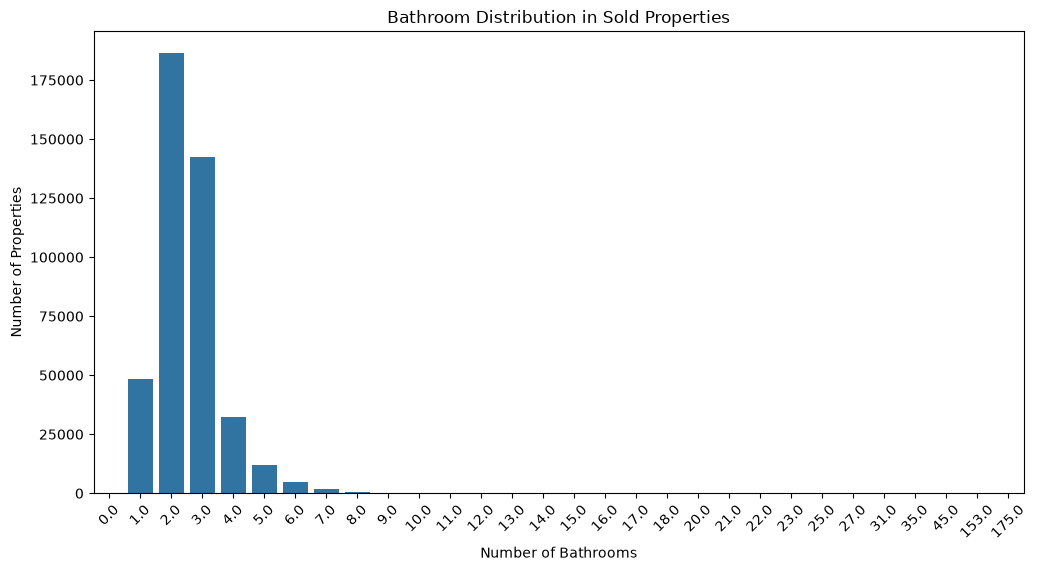

In [45]:
plt.figure(figsize=(12, 6))
sns.countplot(x="BathroomsTotalInteger", data = df_sold)
plt.xticks(rotation=45)
plt.title('Bathroom Distribution in Sold Properties')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Number of Properties')
plt.show()

## 6) Days on Market

In [46]:
df_sold["DaysOnMarket"].describe()

count    429040.000000
mean         37.377715
std          53.676911
min        -288.000000
25%           8.000000
50%          18.000000
75%          48.000000
max       12430.000000
Name: DaysOnMarket, dtype: float64

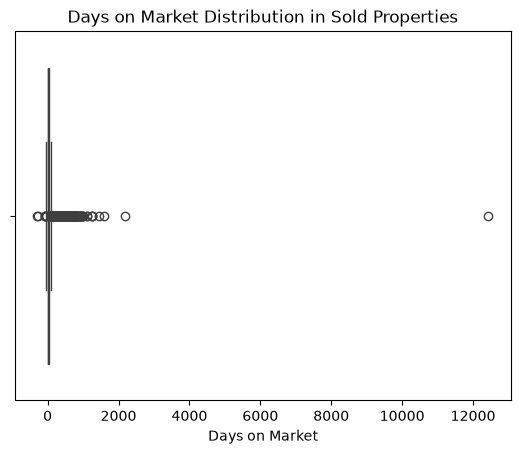

In [47]:
sns.boxplot(x=df_sold["DaysOnMarket"])
plt.title("Days on Market Distribution in Sold Properties")
plt.xlabel("Days on Market")
plt.show()

In [48]:
neg_days_market = df_sold[df_sold["DaysOnMarket"]<0]

print(neg_days_market.shape)
neg_days_market["DaysOnMarket"]

(49, 55)


7458      -36
12442     -10
20313     -10
21216     -13
23931     -13
24711      -6
24751     -10
25423      -2
27863      -2
27937     -19
30096      -5
31161     -14
32073      -3
33063     -58
34560      -1
34623     -48
34982     -57
35255      -6
49474      -2
68211      -2
68410     -43
85394     -84
88858     -18
90737      -1
127505    -56
146190     -8
172698     -6
203477   -288
211998     -5
229290     -4
233340     -3
234479    -12
246319    -34
263281     -7
265843    -26
271810     -9
282102    -63
300578    -14
321723    -21
327790     -7
329693     -4
331067     -2
334152    -65
334230   -265
346723     -4
371718    -14
411387    -39
417517     -4
421981     -1
Name: DaysOnMarket, dtype: int64

In [49]:
upper_limit  = df_sold["DaysOnMarket"].quantile(0.99)

print(df_sold[df_sold["DaysOnMarket"]>=upper_limit].shape)
print(df_sold[df_sold["DaysOnMarket"]>=upper_limit]["DaysOnMarket"].sort_values(ascending=False))
df_sold[df_sold["DaysOnMarket"]>=upper_limit].head()

(4331, 55)
105233    12430
382881     2177
354688     1580
336436     1451
352052     1262
335485     1256
377363     1243
243268     1099
425803     1098
342561      985
38721       985
214592      974
214285      966
387873      944
33871       943
228566      939
166085      935
178899      934
11966       912
353420      894
355875      886
204397      877
83723       864
231664      855
333586      844
13773       833
421016      831
184888      825
313352      820
144147      820
178907      807
385397      806
285478      798
195088      788
140888      780
8963        777
380362      773
418094      768
84055       768
325018      766
68569       765
215564      763
83971       760
390743      756
347634      755
182899      744
326866      731
422861      730
133768      728
145473      728
198966      728
272572      728
267173      727
323739      726
122308      723
416812      723
416847      723
76830       722
83653       717
181854      714
115831      708
165798      7

,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,...,Levels,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerAgencyCompensationType,BuyerAgencyCompensation,SaleListRatio,DiffCloseList,PriceReduction
334,"Carpet,Tile,Vinyl",True,False,399000.0,1031732455,2024-01-02,345000.0,Shelly,Jouett,37.496895,...,Two,False,2.0,Mariposa County Unified,95338,NaN,NaN,0.985714,-5000.0,49000.0
386,NaN,False,NaN,8500000.0,1033955925,2024-01-02,7500000.0,Tim,Allen,NaN,...,NaN,False,0.0,Carmel Unified,93923,NaN,NaN,0.882353,-1000000.0,0.0
829,"Carpet,Stone",True,False,3650000.0,1035855759,2024-01-03,3350000.0,David,Remedios,35.695611,...,One,False,3.0,NaN,93446,NaN,NaN,0.917808,-300000.0,0.0
873,NaN,True,False,1149000.0,1031747562,2024-01-03,1150000.0,Ghydan,Rabadi,34.140591,...,One,False,2.0,Glendale Unified,91204,NaN,NaN,1.004367,5000.0,4000.0
897,"Carpet,Tile",True,False,390000.0,1033337195,2024-01-03,350000.0,Marlene,Bridges,33.607355,...,One,False,0.0,Saddleback Valley Unified,92637,NaN,NaN,0.972222,-10000.0,30000.0


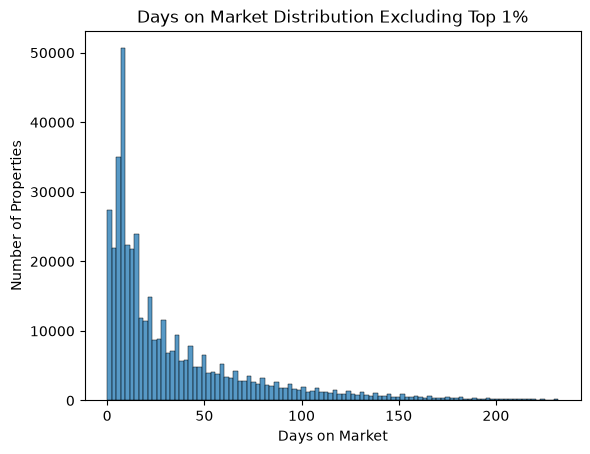

In [50]:
df_sold = df_sold[df_sold["DaysOnMarket"]>= 0]

sns.histplot(df_sold[df_sold["DaysOnMarket"] <= upper_limit]["DaysOnMarket"], bins=100)
plt.title("Days on Market Distribution Excluding Top 1%")
plt.xlabel("Days on Market")
plt.ylabel("Number of Properties")
plt.show()

In [51]:
def dom_split(days):
    if days <=30:
        return "fast sale"
    
    elif days>30 and days <=90:
        return "moderate sale"
    
    elif days >90 and days<=180:
        return "slow sale"
    
    elif days > 180:
        return "long time sale"

df_sold["DOM_category"] = df_sold["DaysOnMarket"].apply(dom_split)

df_sold["DOM_category"].value_counts(normalize=True).sort_values(ascending=False)

DOM_category
fast sale         0.629999
moderate sale     0.263101
slow sale         0.085268
long time sale    0.021632
Name: proportion, dtype: float64

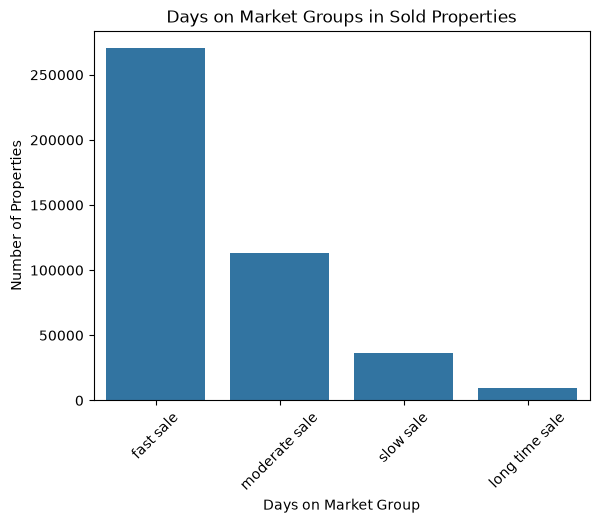

In [52]:
sns.countplot(x="DOM_category",data= df_sold)

plt.title("Days on Market Groups in Sold Properties")
plt.xlabel("Days on Market Group")
plt.ylabel("Number of Properties")
plt.xticks(rotation=45)
plt.show()

## 7) Year Built

In [53]:
df_sold["YearBuilt"].describe()

count    428647.000000
mean       1978.626147
std          26.282074
min        1776.000000
25%        1960.000000
50%        1979.000000
75%        1999.000000
max        2026.000000
Name: YearBuilt, dtype: float64

In [54]:
df_sold["PropertyAge"] = 2026 - df_sold["YearBuilt"]

df_sold["PropertyAge"].value_counts(normalize=True).sort_values(ascending=False)

PropertyAge
37.0     0.021489
2.0      0.019426
38.0     0.019030
47.0     0.018778
46.0     0.018341
39.0     0.018045
36.0     0.018005
53.0     0.017562
41.0     0.017457
21.0     0.017327
40.0     0.017142
48.0     0.017114
49.0     0.016806
54.0     0.016417
71.0     0.016158
22.0     0.016009
20.0     0.015913
1.0      0.015682
62.0     0.015645
42.0     0.015045
52.0     0.014620
23.0     0.014296
45.0     0.014240
61.0     0.013671
63.0     0.013659
70.0     0.013631
55.0     0.013438
64.0     0.013207
72.0     0.013186
76.0     0.013062
66.0     0.013041
67.0     0.012978
50.0     0.012917
3.0      0.011772
51.0     0.011588
73.0     0.011581
24.0     0.011378
19.0     0.011186
56.0     0.010972
65.0     0.010899
26.0     0.010892
35.0     0.010890
74.0     0.010521
75.0     0.010496
25.0     0.010291
68.0     0.010263
69.0     0.010225
43.0     0.010092
57.0     0.009756
27.0     0.009630
58.0     0.009437
60.0     0.008737
8.0      0.008625
78.0     0.008613
28.0     0.00851

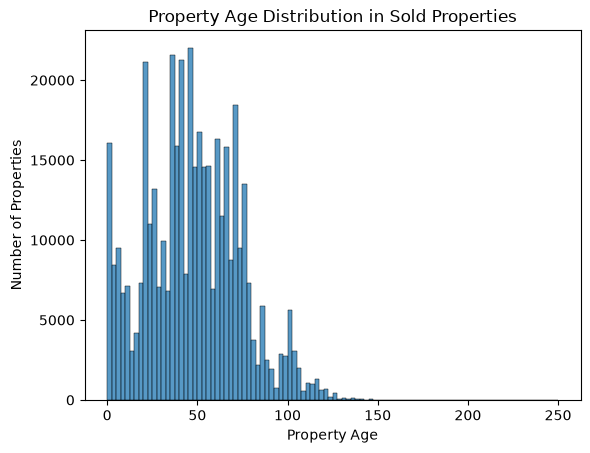

In [55]:
sns.histplot(df_sold["PropertyAge"], bins=100)

plt.title("Property Age Distribution in Sold Properties")
plt.xlabel("Property Age")
plt.ylabel("Number of Properties")
plt.show()

In [56]:
def age_split(ages):
    if ages<=5:
        return "0-5"
    
    elif ages > 5 and ages<=10:
        return "6-10"
    
    elif ages>10 and ages <=20:
        return "11-20"
    
    elif ages>20 and ages<=40:
        return "21-40"
    
    elif ages>40 and ages<=70:
        return "41-70"
    
    elif ages>70:
        return "70+"

df_sold["PropertyAgeGroup"] = df_sold["PropertyAge"].apply(age_split)

df_sold["PropertyAgeGroup"].value_counts(normalize=True)

PropertyAgeGroup
41-70    0.395531
21-40    0.249959
70+      0.193005
0-5      0.064631
11-20    0.060490
6-10     0.036384
Name: proportion, dtype: float64

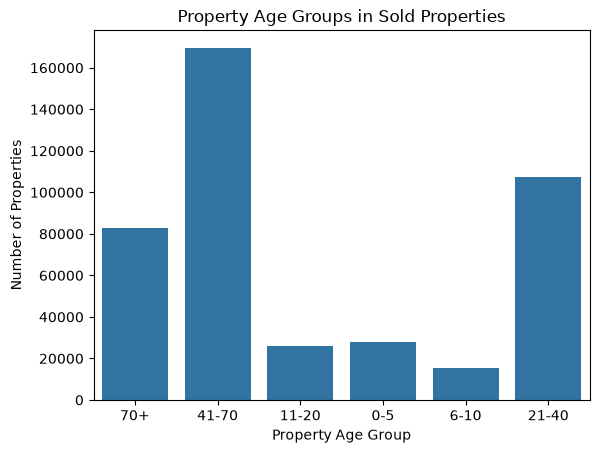

In [71]:
sns.countplot(x="PropertyAgeGroup", data = df_sold)

plt.title("Property Age Groups in Sold Properties")
plt.xlabel("Property Age Group")
plt.ylabel("Number of Properties")
plt.show()

In [58]:
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"
mortgage = pd.read_csv(url, parse_dates=['observation_date'])
mortgage.head()

,observation_date,MORTGAGE30US
0,1971-04-02,7.33
1,1971-04-09,7.31
2,1971-04-16,7.31
3,1971-04-23,7.31
4,1971-04-30,7.29


In [59]:

mortgage.columns = ['date', 'rate_30yr_fixed']

mortgage['year_month'] = mortgage['date'].dt.to_period('M')
mortgage.head()

,date,rate_30yr_fixed,year_month
0,1971-04-02,7.33,1971-04
1,1971-04-09,7.31,1971-04
2,1971-04-16,7.31,1971-04
3,1971-04-23,7.31,1971-04
4,1971-04-30,7.29,1971-04


In [60]:
mortgage_monthly = (
    mortgage.groupby('year_month')['rate_30yr_fixed']
    .mean()
    .reset_index()
)

mortgage_monthly.head()

,year_month,rate_30yr_fixed
0,1971-04,7.3100
1,1971-05,7.4250
2,1971-06,7.5300
3,1971-07,7.6040
4,1971-08,7.6975


In [67]:
df_sold['year_month'] = pd.to_datetime(df_sold['CloseDate']).dt.to_period('M')

df_sold = df_sold.merge(mortgage_monthly, on='year_month', how='left')

df_sold["rate_30yr_fixed"].head()

0    6.6425
1    6.6425
2    6.6425
3    6.6425
4    6.6425
Name: rate_30yr_fixed, dtype: float64

In [65]:
print(df_sold['rate_30yr_fixed'].isnull().sum())


0
